# Predict \u2014 reload the winner model and forecast the next week

Scheduled-forecast companion to `model.ipynb`. We pick up whichever model
won in `model.ipynb \u00a74` (recorded in `winner_run_meta.json`) and produce a
next-week forecast bundle for the dashboards. Two code paths, one output:

| winner kind       | how we recover the fitted model                     | time  |
|-------------------|-----------------------------------------------------|-------|
| Bayesian (v0\u2013v4) | `BayesianRung.from_saved(winner_model.npz)` \u2014 no MCMC | ~1 s  |
| XGBoost / OLS / naive baseline | re-fit the baseline class on the same train+val slice \u00a76 used (no bundle to save) | 30\u201360 s |

Inputs (written by `model.ipynb \u00a77`):

- `winner_run_meta.json`  \u2014 winner name, kind, metrics (under whatever
  `ARTIFACT_DIR` the training kernel used \u2014 often
  `notebooks/modeling/artifacts/modeling/` if Jupyter\u2019s cwd was
  `notebooks/modeling/`)
- `winner_model.npz`      \u2014 **Bayesian only**: posterior parameter samples

This notebook **auto-finds** the meta file under the repo root or
`notebooks/modeling/artifacts/modeling/`. Override with env
`DATATIDE_MODELING_ARTIFACTS` if yours lives elsewhere.

Outputs (written by this notebook):

- `artifacts/modeling/winner_next_week_forecast.parquet` \u2014 **tidy, Power-BI ready**
- `artifacts/modeling/winner_next_week_samples.npz`      \u2014 raw `(S, N_future)` log10 draws
- `artifacts/modeling/winner_next_week_index.parquet`    \u2014 `row_idx \u2192 station/date`
- `artifacts/modeling/winner_next_week_meta.json`        \u2014 manifest

Switch scenarios by editing `HORIZON_DAYS` / `START_DATE` / `WEATHER_OVERRIDE`
below. Typical weather = monthly climatology from pre-test rows (the default).


## \u00a70. Setup


In [1]:
import os, warnings, json, time
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")
# Prediction is cheap \u2014 stay on CPU so this runs anywhere.
os.environ["JAX_PLATFORMS"] = os.environ.get("FORCE_JAX_PLATFORM", "cpu")
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
PROJ = Path.cwd().resolve()
while not (PROJ / "src").exists() and PROJ != PROJ.parent:
    PROJ = PROJ.parent
sys.path.insert(0, str(PROJ))

from src.modeling.cv         import load_panel
from src.modeling.inference  import BayesianRung
from src.modeling.baselines  import NaiveSeasonalMeanCounts, OLSLog10, XGBoostLog10
from src.modeling.production import (
    build_future_fold, compute_climatology, export_forecast_bundle,
    read_forecast_frame,
)
from src.evaluation.compare  import FoldData

plt.rcParams.update({"figure.dpi": 100, "font.size": 9})


def _resolve_modeling_artifact_dir(proj: Path) -> Path:
    # Where model.ipynb wrote winner_run_meta.json.
    # model.ipynb uses Path("artifacts/modeling") relative to the kernel cwd.
    # If Jupyter cwd is notebooks/modeling/, artifacts are under
    # notebooks/modeling/artifacts/modeling/, not repo-root artifacts/modeling/.
    # Override: export DATATIDE_MODELING_ARTIFACTS=/abs/path/to/dir_with_meta
    meta_name = "winner_run_meta.json"
    env = os.environ.get("DATATIDE_MODELING_ARTIFACTS", "").strip()
    if env:
        p = Path(env).expanduser().resolve()
        if not (p / meta_name).is_file():
            raise FileNotFoundError(
                f"DATATIDE_MODELING_ARTIFACTS={env!r} but {meta_name} not found there"
            )
        return p

    candidates = [
        proj / "artifacts" / "modeling",
        proj / "notebooks" / "modeling" / "artifacts" / "modeling",
        Path.cwd().resolve() / "artifacts" / "modeling",
        Path.cwd().resolve() / "notebooks" / "modeling" / "artifacts" / "modeling",
    ]
    for c in candidates:
        c = c.resolve()
        if (c / meta_name).is_file():
            return c

    return (proj / "artifacts" / "modeling").resolve()


ARTIFACT_DIR = _resolve_modeling_artifact_dir(PROJ)
print(f"project root : {PROJ}")
print(f"artifact dir : {ARTIFACT_DIR}  (exists={ARTIFACT_DIR.is_dir()})")
if not (ARTIFACT_DIR / "winner_run_meta.json").is_file():
    print(
        "  \u26a0  winner_run_meta.json not found in any standard location.\n"
        "     Run model.ipynb through \u00a77 first, or set env DATATIDE_MODELING_ARTIFACTS,\n"
        "     or assign:  ARTIFACT_DIR = Path(\".../artifacts/modeling\")"
    )


project root : /Users/buttz/Desktop/projects/DataTide
artifact dir : /Users/buttz/Desktop/projects/DataTide/notebooks/modeling/artifacts/modeling  (exists=True)


## \u00a71. Recover the winner

Reads `winner_run_meta.json` and dispatches on the winner kind:

- **Bayesian winner** \u2192 `BayesianRung.from_saved(winner_model.npz)`. Instant,
  no MCMC. The posterior parameter samples come out of the `.npz` the
  training run wrote.
- **Baseline winner** (naive / OLS / XGBoost) \u2192 rebuild the class fresh and
  `.fit(...)` it on the exact same pre-2024 slice (`cv_val_year >= 0`) that
  `model.ipynb \u00a76` retrained on. Baselines are cheap to fit (~30 s for
  XGBoost on ~300 K rows) so we don't bother pickling them.

Either way, `final_model.predict(fold)` afterwards conforms to the same
`Forecaster` protocol, so the rest of this notebook is winner-agnostic.


In [2]:
RUN_META = ARTIFACT_DIR / "winner_run_meta.json"
if not RUN_META.is_file():
    raise FileNotFoundError(
        f"Missing {RUN_META}\n"
        f"Resolved ARTIFACT_DIR = {ARTIFACT_DIR}\n\n"
        "model.ipynb writes ARTIFACT_DIR = Path('artifacts/modeling') relative to the "
        "Jupyter kernel cwd. If you ran it from notebooks/modeling/, the meta file is "
        "usually at:\n"
        f"  {(PROJ / 'notebooks' / 'modeling' / 'artifacts' / 'modeling' / 'winner_run_meta.json')}\n\n"
        "Fix: re-run model.ipynb through \u00a77, or set env DATATIDE_MODELING_ARTIFACTS to the "
        "directory that contains winner_run_meta.json, or after the setup cell assign:\n"
        "  ARTIFACT_DIR = Path(\"notebooks/modeling/artifacts/modeling\").resolve()"
    )

with open(RUN_META) as fh:
    run_meta = json.load(fh)

print("winner        :", run_meta["winner"])
print("rung          :", run_meta["rung"])
print("is_bayesian   :", run_meta["is_bayesian"])
print("test counts-MAE  :", run_meta["test_score"].get("counts-MAE"))

BASELINE_CLASSES = {
    "B1 naive seasonal-mean (by month)": NaiveSeasonalMeanCounts,
    "B2 OLS log10":                       OLSLog10,
    "B3 XGBoost log10":                   XGBoostLog10,
}


def _build_baseline_train_fold(bundle, train_mask):
    # Shape-compatible FoldData carrying only training data.
    # Baselines' .fit(fold) reads the _train side only; we stub the _val
    # side with zero-length arrays so the dataclass is valid. Actual future
    # rows get supplied later via build_future_fold(...) + .predict(...).
    return FoldData(
        fold_val_year=-1,
        y_log_train=bundle.y_log[train_mask],
        month_train=bundle.month[train_mask],
        station_idx_train=bundle.station_idx[train_mask],
        county_idx_train=bundle.county_idx[train_mask],
        X_smooth_train=bundle.X_smooth[train_mask],
        X_linear_train=bundle.X_linear[train_mask],
        miss_smooth_train=bundle.miss_smooth[train_mask],
        miss_linear_train=bundle.miss_linear[train_mask],
        left_mask_train=bundle.left_mask[train_mask],
        right_mask_train=bundle.right_mask[train_mask],
        det_low_log_train=bundle.det_low_log[train_mask],
        det_high_log_train=bundle.det_high_log[train_mask],
        y_log_val=np.zeros(0, dtype=np.float32),
        month_val=np.zeros(0, dtype=np.int8),
        station_idx_val=np.zeros(0, dtype=np.int32),
        county_idx_val=np.zeros(0, dtype=np.int32),
        X_smooth_val=np.zeros((0, bundle.X_smooth.shape[1]), dtype=np.float32),
        X_linear_val=np.zeros((0, bundle.X_linear.shape[1]), dtype=np.float32),
        miss_smooth_val=np.zeros((0, bundle.miss_smooth.shape[1]), dtype=np.int8),
        miss_linear_val=np.zeros((0, bundle.miss_linear.shape[1]), dtype=np.int8),
        smooth_features=list(bundle.smooth_features),
        linear_features=list(bundle.linear_features),
        n_stations=bundle.n_stations,
        n_counties=bundle.n_counties,
    )


if run_meta["is_bayesian"]:
    winner_path = ARTIFACT_DIR / run_meta["artifacts"]["model_bundle"]
    t0 = time.time()
    final_model = BayesianRung.from_saved(winner_path)
    print(f"\nreloaded Bayesian winner in {time.time()-t0:.2f}s  \u2014  {final_model.name}")
    print(f"posterior sample keys : {list(final_model._posterior_samples.keys())}")
    n_draws = next(iter(final_model._posterior_samples.values())).shape[0]
    print(f"total posterior draws : {n_draws}")
else:
    cls = BASELINE_CLASSES.get(run_meta["winner"])
    if cls is None:
        raise RuntimeError(
            f"Unknown baseline winner name {run_meta['winner']!r}; "
            f"supported: {list(BASELINE_CLASSES)}"
        )
    bundle_for_fit = load_panel()
    train_mask = (bundle_for_fit.cv_val_year >= 0)          # pre-2024 = train \u222a val
    train_fold = _build_baseline_train_fold(bundle_for_fit, train_mask)

    final_model = cls()
    print(f"\nrefitting baseline {cls.__name__} on {int(train_mask.sum()):,} rows \u2026")
    t0 = time.time()
    final_model.fit(train_fold)
    print(f"refit in {time.time()-t0:.1f}s  \u2014  {final_model.name}")


winner        : B3 XGBoost log10
rung          : None
is_bayesian   : False
test counts-MAE  : 8542.892357724746

refitting baseline XGBoostLog10 on 354,672 rows …
refit in 50.9s  —  B3 XGBoost log10


## \u00a72. Build the next-week fold

The future fold has one row per (station, day). Date-derived features
(month, doy) come from the dates themselves; weather lag features come from
**monthly climatology** computed on pre-test rows. Override any feature by
editing `WEATHER_OVERRIDE` below.


In [3]:
HORIZON_DAYS    = 7
START_DATE      = None            # None = day after last panel date; set to "YYYY-MM-DD" to force
WEATHER_OVERRIDE: dict[str, np.ndarray] | None = None   # e.g. {"rain_24h_mm": np.full(N, 2.0)}

bundle = load_panel()
print(f"panel: n={len(bundle.y_log):,}  n_stations={bundle.n_stations}  "
      f"last date={str(np.datetime64(bundle.date_min) + np.timedelta64(int(bundle.t_idx.max()), 'D'))[:10]}")

clim = compute_climatology(bundle, use_rows=(bundle.cv_val_year >= 0))

# Carry the pre-2024 slice through on the train side so, for baseline winners,
# `final_model.predict(future_fold)` still has the right design reference
# (Bayesian winners ignore the train side \u2014 harmless either way).
future_fold, future_index = build_future_fold(
    bundle,
    start_date=START_DATE,
    horizon_days=HORIZON_DAYS,
    climatology=clim,
    weather_override=WEATHER_OVERRIDE,
    training_mask=(bundle.cv_val_year >= 0),
)
print(f"future fold: {len(future_index):,} rows  "
      f"({future_index['date'].min().date()} \u2192 {future_index['date'].max().date()})")
future_index.head()


panel: n=411,772  n_stations=778  last date=2025-12-31
future fold: 5,446 rows  (2026-01-01 → 2026-01-07)


,row_idx,date,station_idx,station_id,station_name,county_idx,county_name,month,doy
0,0,2026-01-01,0,1,0,7,Orange,1,1
1,1,2026-01-01,1,2,1000,15,Ventura,1,1
2,2,2026-01-01,2,3,10000,15,Ventura,1,1
3,3,2026-01-01,3,5,1050,15,Ventura,1,1
4,4,2026-01-01,4,6,1100,15,Ventura,1,1


## \u00a73. Predictive draws for the future fold

`final_model.predict(future_fold)` returns a `(S, N_future)` matrix of log10
MPN draws. The semantics depend on the winner kind:

- **Bayesian winner:** genuine posterior-predictive samples \u2014 propagates
  parameter uncertainty + observation noise.
- **Baseline winner (naive / OLS / XGBoost):** point prediction +
  `Normal(mu_hat, sigma_train_resid)` noise, i.e. a residual-based
  pseudo-predictive (see `MODELING_PLAN.md \u00a76.3`). It does **not** capture
  parameter uncertainty for XGBoost, so 80/95 % PI from this bundle under-
  covers relative to the Bayesian version \u2014 teammates should expect
  narrower intervals if the winner was a baseline.

Point forecast is `median(10**samples)` per row in either case; intervals
are quantiles of `10**samples`.


In [4]:
t0 = time.time()
future_pred = final_model.predict(future_fold)
print(f"predicted in {time.time()-t0:.1f}s   samples shape = {future_pred.samples_log10.shape}")


predicted in 1.1s   samples shape = (2000, 5446)


## \u00a74. Export the teammate bundle

One call writes the four files the dashboards consume:

| file | purpose |
|---|---|
| `winner_next_week_forecast.parquet` | tidy median / PI / exceedance per (station, date) \u2014 Power BI |
| `winner_next_week_samples.npz`      | raw `(S, N_future)` log10 draws \u2014 internal web |
| `winner_next_week_index.parquet`    | `row_idx \u2192 (station, date, county)` lookup |
| `winner_next_week_meta.json`        | shapes + dates + provenance |


In [5]:
written = export_forecast_bundle(
    ARTIFACT_DIR,
    tag="winner_next_week",
    index_df=future_index,
    samples_log10=future_pred.samples_log10,
    meta_extra={
        "winner":            run_meta["winner"],
        "rung":              run_meta["rung"],
        "horizon_days":      HORIZON_DAYS,
        "weather_strategy":  ("monthly climatology (pre-2024)" if WEATHER_OVERRIDE is None
                              else f"climatology + override keys={list(WEATHER_OVERRIDE)}"),
        "start_date":        str(future_index['date'].min().date()),
    },
)
for k, p in written.items():
    print(f"wrote {k:<8s}  \u2192 {p}")


wrote forecast  → /Users/buttz/Desktop/projects/DataTide/notebooks/modeling/artifacts/modeling/winner_next_week_forecast.parquet
wrote samples   → /Users/buttz/Desktop/projects/DataTide/notebooks/modeling/artifacts/modeling/winner_next_week_samples.npz
wrote index     → /Users/buttz/Desktop/projects/DataTide/notebooks/modeling/artifacts/modeling/winner_next_week_index.parquet
wrote meta      → /Users/buttz/Desktop/projects/DataTide/notebooks/modeling/artifacts/modeling/winner_next_week_meta.json


## \u00a75. Preview \u2014 tidy table + advisory heatmap

Same view the dashboard will render. Counties are sorted by earliest-day
exceedance risk (highest at top) so the most actionable advisory stands out.


,row_idx,date,station_idx,station_id,station_name,county_idx,county_name,month,doy,point_mpn_median,point_log10_median,pi50_low_mpn,pi50_high_mpn,pi80_low_mpn,pi80_high_mpn,pi95_low_mpn,pi95_high_mpn,p_exceed_104mpn
0,0,2026-01-01,0,1,0,7,Orange,1,1,15.379015,1.186929,7.417879,32.922939,3.716027,65.271129,1.735708,143.728085,0.0435
1,1,2026-01-01,1,2,1000,15,Ventura,1,1,23.123953,1.364062,10.674439,50.247915,5.298789,92.422128,2.414068,191.098709,0.0825
2,2,2026-01-01,2,3,10000,15,Ventura,1,1,24.042782,1.380983,11.180799,49.804932,5.810468,98.538454,2.632451,206.368775,0.0900
3,3,2026-01-01,3,5,1050,15,Ventura,1,1,23.556400,1.372109,10.668775,49.964301,5.512583,96.173048,2.529228,196.372776,0.0935
4,4,2026-01-01,4,6,1100,15,Ventura,1,1,22.537888,1.352913,10.807450,48.244043,5.661634,96.399600,2.788494,214.474245,0.0855
5,5,2026-01-01,5,7,11000,15,Ventura,1,1,23.451450,1.370170,10.995762,52.129547,5.406073,102.165592,2.613494,200.173663,0.0980
6,6,2026-01-01,6,9,12N,7,Orange,1,1,14.866169,1.172199,6.938165,31.346122,3.622400,66.820186,1.678411,151.213134,0.0490
7,7,2026-01-01,7,11,13000,15,Ventura,1,1,23.447115,1.370089,11.529393,48.256960,5.645454,91.325039,2.733472,192.030372,0.0785
8,8,2026-01-01,8,13,14000,15,Ventura,1,1,22.392723,1.350107,10.823875,47.717160,5.925692,98.669558,2.552419,198.980000,0.0895
9,9,2026-01-01,9,14,15000,15,Ventura,1,1,22.779663,1.357547,10.501468,47.094489,5.485264,94.458106,2.614343,192.032458,0.0875


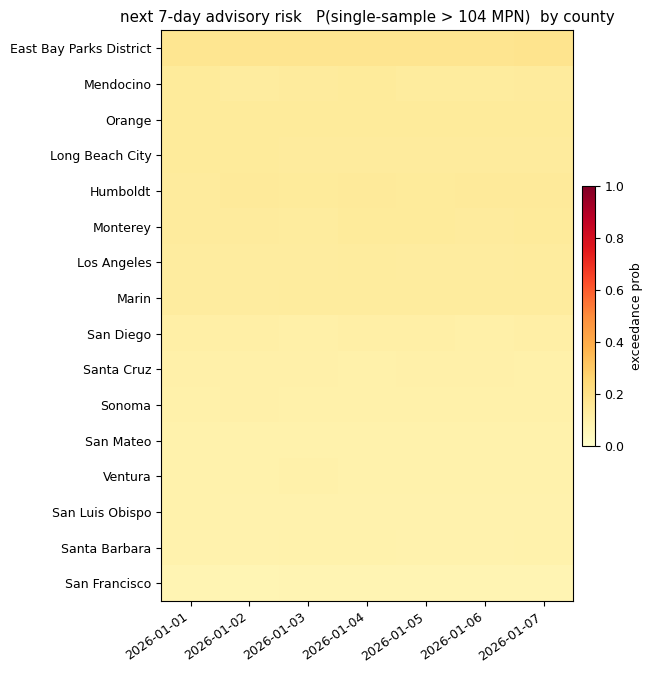

In [6]:
tidy = read_forecast_frame(written["forecast"])
display(tidy.head(15))

heat = (
    tidy.assign(date=tidy["date"].dt.date)
        .groupby(["county_name", "date"])["p_exceed_104mpn"]
        .mean()
        .unstack("date")
)
heat = heat.sort_values(by=heat.columns[0], ascending=False)

fig, ax = plt.subplots(figsize=(1 + 0.8 * HORIZON_DAYS, 0.35 * len(heat) + 1.2))
im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(heat.shape[1]))
ax.set_xticklabels([str(d) for d in heat.columns], rotation=35, ha='right')
ax.set_yticks(range(heat.shape[0]))
ax.set_yticklabels(heat.index)
ax.set_title(f"next {HORIZON_DAYS}-day advisory risk   P(single-sample > 104 MPN)  by county")
plt.colorbar(im, ax=ax, label='exceedance prob', fraction=0.03, pad=0.02)
plt.tight_layout(); plt.show()


In [7]:
# Station-level view: top 20 stations by mean next-week exceedance risk.
top20 = (
    tidy.groupby(["station_id", "station_name", "county_name"])["p_exceed_104mpn"]
        .mean()
        .sort_values(ascending=False)
        .head(20)
        .reset_index()
        .rename(columns={"p_exceed_104mpn": "mean_p_exceed_next_week"})
)
display(top20)


,station_id,station_name,county_name,mean_p_exceed_next_week
0,457,IB-030,San Diego,0.238000
1,539,Keller Mid Beach,East Bay Parks District,0.194786
2,155,Crown Bath House,East Bay Parks District,0.191214
3,810,ENCINAL BEACH MID,East Bay Parks District,0.189500
4,760,ENCINAL BEACH NORTH,East Bay Parks District,0.187500
5,552,Keller North Beach,East Bay Parks District,0.185429
6,736,Crown Windsurfer Corner,East Bay Parks District,0.180429
7,724,Crown Sunset Rd.,East Bay Parks District,0.179786
8,203,Crown Bird Sanctuary,East Bay Parks District,0.179643
9,761,ENCINAL BEACH SOUTH,East Bay Parks District,0.177929


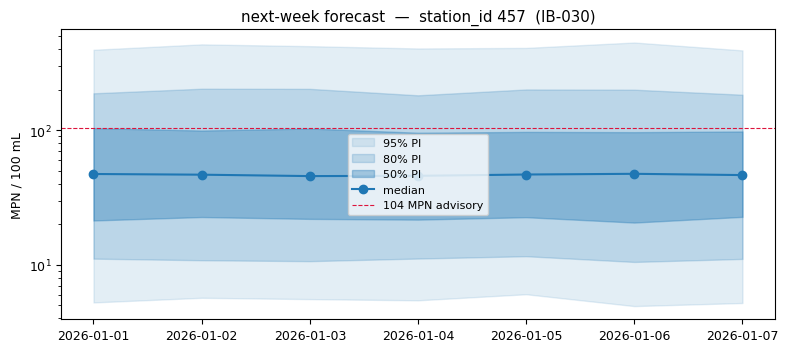

In [8]:
# Sanity: quick residual-free trace-like plot of one station's predictive
# distribution over the week (median + 50/80/95 PI, counts scale, log y-axis).
stn_idx = int(top20.iloc[0]["station_id"])      # highest-risk station id
rows = tidy[tidy["station_id"] == stn_idx].sort_values("date")
if len(rows) > 0:
    fig, ax = plt.subplots(figsize=(8, 3.6))
    x = pd.to_datetime(rows["date"])
    ax.fill_between(x, rows["pi95_low_mpn"], rows["pi95_high_mpn"], alpha=0.12, color='C0', label='95% PI')
    ax.fill_between(x, rows["pi80_low_mpn"], rows["pi80_high_mpn"], alpha=0.2,  color='C0', label='80% PI')
    ax.fill_between(x, rows["pi50_low_mpn"], rows["pi50_high_mpn"], alpha=0.35, color='C0', label='50% PI')
    ax.plot(x, rows["point_mpn_median"], 'o-', color='C0', label='median')
    ax.axhline(104, ls='--', color='crimson', lw=0.8, label='104 MPN advisory')
    ax.set_yscale('log')
    ax.set_ylabel("MPN / 100 mL")
    ax.set_title(f"next-week forecast  \u2014  station_id {stn_idx}  ({rows.iloc[0]['station_name']})")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


## Next steps

- Schedule this notebook on cron (or a CI job) so a fresh bundle is written
  once a week. Nothing about it requires an interactive kernel.
- If forecasts drift from reality for >N weeks, re-run `model.ipynb` end-to-end
  so the panel, priors, and posterior get refreshed.
- For a **storm** scenario, set e.g.
  `WEATHER_OVERRIDE = {"rain_24h_mm": np.full(n_future, 25.0)}` at the top of
  \u00a72 and re-run \u00a72\u2013\u00a75. The exported artifacts overwrite the "typical" bundle
  \u2014 rename the output tag if you want to keep both.
